In [1]:
import sys, os
from pathlib import Path

cwd  = Path.cwd().resolve()
ROOT = cwd if (cwd / 'src').exists() else cwd.parent
sys.path.insert(0, str(ROOT))
os.chdir(ROOT)

print(f'ROOT : {ROOT}')


ROOT : C:\son_spatialisation


In [2]:
from src.multimodal import SphericalHarmonicsTransform, SHVisualizer
import sofa
import numpy as np
from pathlib import Path

ROOT    = Path.cwd() if Path.cwd().name == 'son_spatialisation' else Path.cwd().parent
SOFA_D1 = ROOT / 'dataset/Database-Master_V2-1/D1/D1_HRIR_SOFA/D1_44K_16bit_256tap_FIR_SOFA.sofa'


In [4]:
sh = SphericalHarmonicsTransform(order=5)

# Encode : HRTF [N_pos, 129, 2]  →  coefficients SH [36, 129, 2]
coeffs = sh.encode_subject(SOFA_D1)

print(f'Shape coefficients : {coeffs.shape}')*
print(f'  → (L+1)² = {sh.n_sh} modes  ×  129 fréquences  ×  2 oreilles')
print(f'  min={coeffs.min():.2f} dB   max={coeffs.max():.2f} dB')


Shape coefficients : (36, 129, 2)
  → (L+1)² = 36 modes  ×  129 fréquences  ×  2 oreilles
  min=-66.50 dB   max=36.78 dB


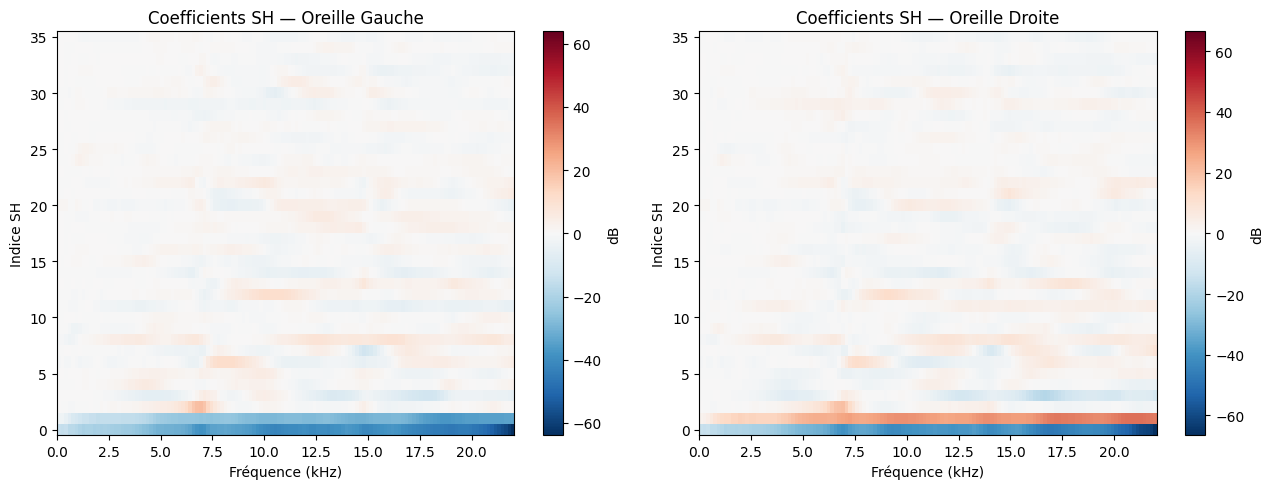

In [5]:
viz = SHVisualizer(sh)
viz.plot_coefficients(coeffs)

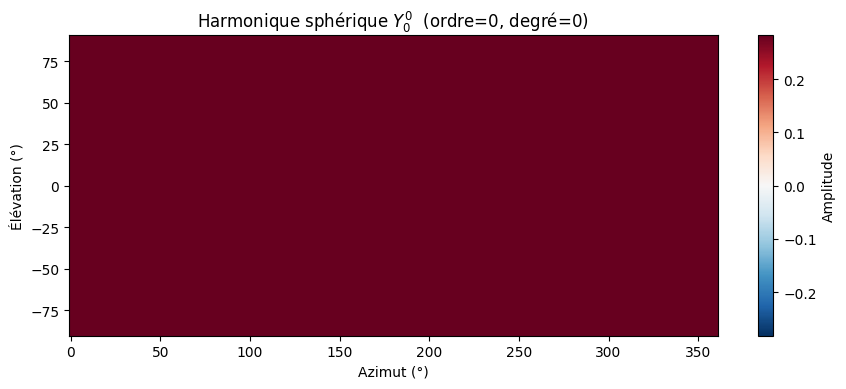

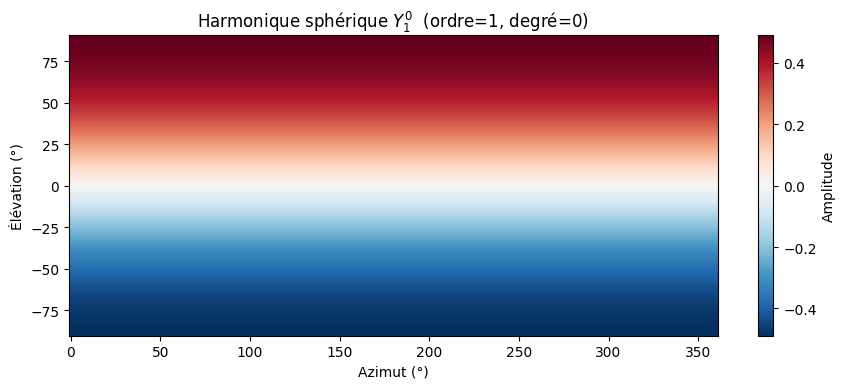

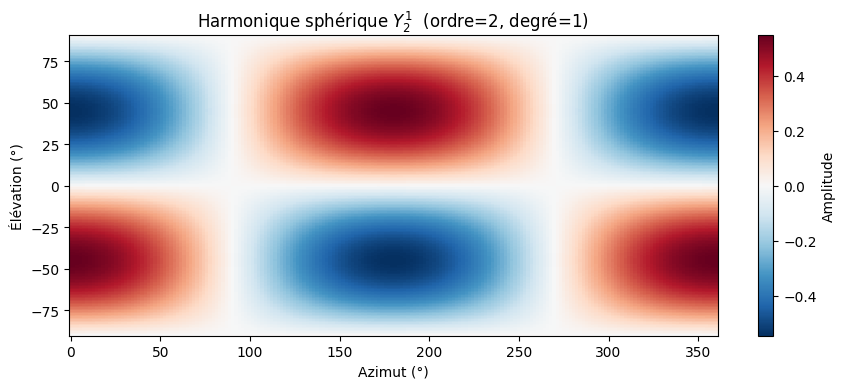

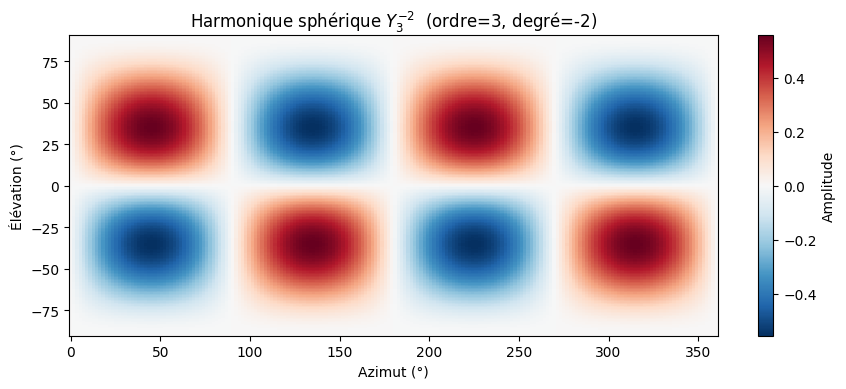

In [6]:
# Affiche la carte spatiale de Y_l^m sur la sphère
viz.plot_basis(l=0, m=0)   # mode 0 : omnidirectionnel

viz.plot_basis(l=1, m=0)   # mode 1 : dipôle haut/bas

viz.plot_basis(l=2, m=1)   # mode 2 : quadrupôle
viz.plot_basis(l=3, m=-2)  # mode 3 : octopôle

In [7]:
# Charger les positions originales pour la reconstruction
db        = sofa.Database.open(str(SOFA_D1))
positions = db.SourcePosition.get_values()[:, :2]   # [N_pos, 2] az/el en degrés
irs       = db.Data.IR.get_values()                  # [N_pos, 2, 256]
db.close()

# HRTF originale en log-magnitude
spectrum = np.fft.rfft(irs, axis=-1)
log_mag  = 20.0 * np.log10(np.abs(spectrum) + 1e-8)
hrtf_orig = np.transpose(log_mag, (0, 2, 1)).astype(np.float32)  # [N_pos, 129, 2]

# Reconstruction depuis les coefficients SH
hrtf_recon = sh.decode(coeffs, positions)

print(f'HRTF originale   : {hrtf_orig.shape}')
print(f'HRTF reconstruite: {hrtf_recon.shape}')


HRTF originale   : (8802, 129, 2)
HRTF reconstruite: (8802, 129, 2)


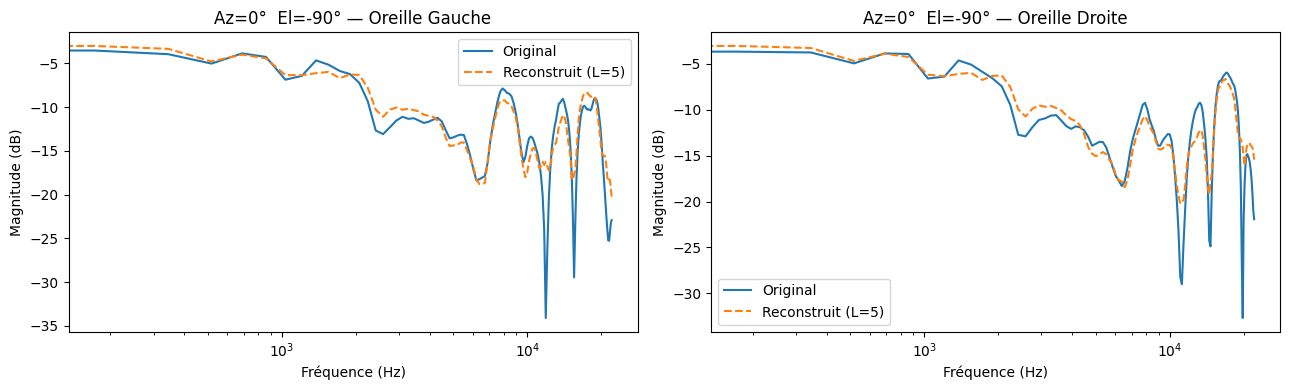

In [8]:
# Affiche la direction 0 (azimut=0°, élévation=0° en général)
viz.plot_reconstruction(hrtf_orig, coeffs, positions, position_idx=0)


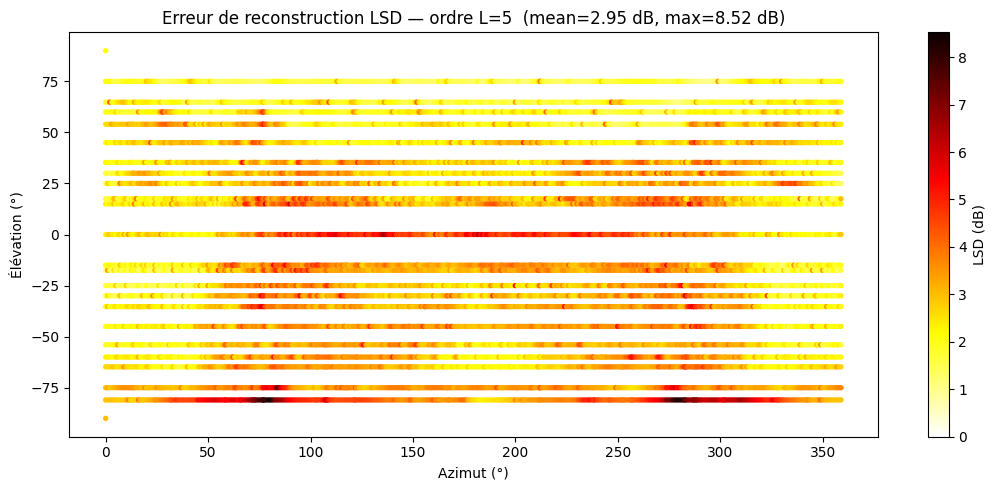

In [9]:
viz.plot_reconstruction_error(hrtf_orig, coeffs, positions)


L= 2  n_sh=   9  LSD=4.025 dB  temps=10.58s
L= 5  n_sh=  36  LSD=2.950 dB  temps=17.37s
L=10  n_sh= 121  LSD=2.231 dB  temps=2.28s
L=20  n_sh= 441  LSD=1.632 dB  temps=43.61s
L=30  n_sh= 961  LSD=1.330 dB  temps=65.55s
L=40  n_sh=1681  LSD=34939.148 dB  temps=20.37s
L=50  n_sh=2601  LSD=40566.133 dB  temps=43.35s


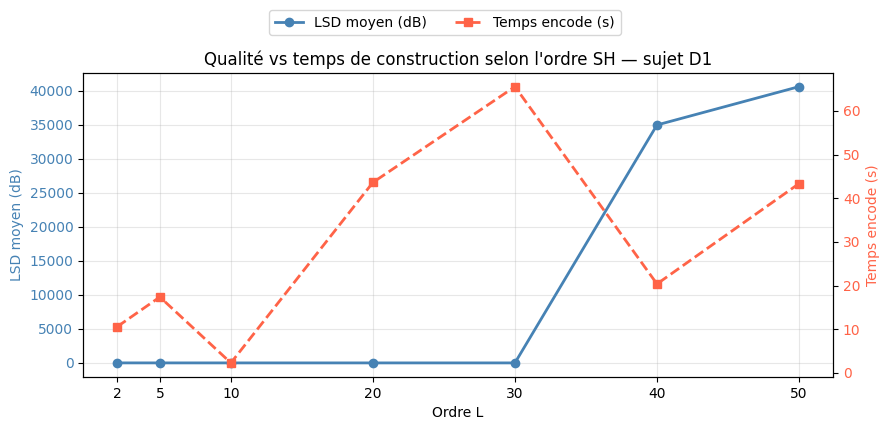

In [10]:
import matplotlib.pyplot as plt
import time

orders   = [2, 5, 10, 20, 30, 40, 50]
mean_lsd = []
times    = []

for L in orders:
    sh_L  = SphericalHarmonicsTransform(order=L)

    t0 = time.perf_counter()
    c  = sh_L.encode_subject(SOFA_D1)
    elapsed = time.perf_counter() - t0

    recon = sh_L.decode(c, positions)
    lsd   = np.sqrt(np.mean((hrtf_orig - recon) ** 2, axis=(1, 2)))

    mean_lsd.append(lsd.mean())
    times.append(elapsed)
    print(f'L={L:2d}  n_sh={(L+1)**2:4d}  LSD={lsd.mean():.3f} dB  temps={elapsed:.2f}s')

# Double axe Y : LSD à gauche, temps à droite
fig, ax1 = plt.subplots(figsize=(9, 4))

ax1.plot(orders, mean_lsd, 'o-', color='steelblue', linewidth=2, label='LSD moyen (dB)')
ax1.set_xlabel('Ordre L')
ax1.set_ylabel('LSD moyen (dB)', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

ax2 = ax1.twinx()
ax2.plot(orders, times, 's--', color='tomato', linewidth=2, label='Temps encode (s)')
ax2.set_ylabel('Temps encode (s)', color='tomato')
ax2.tick_params(axis='y', labelcolor='tomato')

fig.legend(loc='upper center', ncol=2, bbox_to_anchor=(0.5, 1.08))
ax1.set_title("Qualité vs temps de construction selon l'ordre SH — sujet D1")
ax1.set_xticks(orders)
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
